- Verificar a existência de valores ausentes e decidir como irá lidar com eles.
- Construir um modelo de regressão linear considerando as variáveis que o grupo julgar necessárias (no relatório deve constar uma justificativa da escolha).
- Analisar o modelo obtido (a análise deve considerar se o modelo é significativo, se os parâmetros são significativos e o que isso significa, qual o valor do coeficiente de determinação e o que ele significa. Caso exista parâmetros não significativos, o grupo deve decidir como trata-los e apresentar o modelo final).


- O modelo final deve ser estudado quanto a normalidade dos resíduos, a multicolinearidade e a heterocedasticidade.
- Caso os resíduos não cumpra o pressuposto da normalidade, o grupo deverá realizar uma transformação de variável com a finalidade de normalizar os resíduos.
- Escreva alguma conclusão interessante que pode ser obtida do modelo encontrado.

- Realize uma Análise de Componentes Principais com os dados (não é necessário utilizar todas as variáveis).
- Decida quantos Componentes Principais são necessários.
- Interprete os Componentes Principais.

Estrutura do colab: células de código para manipulação geral (funcionará para outros datasets, contando que se mantenha o mesmo contrato de colunas) e células de markdown destinadas a análise do caso específico do dataset passado para o projeto.

In [3]:
# Importação das bibliotecas necessárias
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statstests.process import stepwise
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
# Definição do dataset e visualização inicial dos dados
caminho = "./dataset/Grupo 8.xlsx"
gross_data = pd.read_excel(caminho)
gross_data.head()

,Jogador,Time,Tent,Compl,Por Tent,TD,PerTD,Int,PF
0,Philip Rivers,SD,478.0,312,8.39,34,7.1,11.0,105.5
1,Chad Pennington,MIA,476.0,321,7.67,19,4.0,7.0,97.4
2,Kurt Warner,ARI,598.0,401,7.66,30,5.0,14.0,96.9
3,Drew Brees,NO,635.0,413,7.98,34,5.4,17.0,96.2
4,Peyton Manning,IND,555.0,371,7.21,27,4.9,12.0,95.0


In [5]:
# Análise inicial do formato dos casos (número de linhas e colunas)
gross_data.shape

(32, 9)

Os dados são compostos de 32 linhas e 9 colunas, isto é, são 32 observações com 9 variáveis.
Dessas variáveis, temos:
- Jogador: nome do jogador (qualitativa nominal)
- Time: nome do time (qualitativa nominal)
- Tent: número de tentativas de passe (quantitativa discreta)
- Compl: número de passes completados (quantitativa discreta)
- Por Tent: número de jardas por tentativa (quantitativa contínua)
- TD: número de passes para touchdown (quantitativa discreta)
- PerTD: porcentagem de tentativas que são touchdown (quantitativa contínua percentual)
- Int: número de interceptações (quantitativa discreta)
- PF: número de pontos feitos (qualitativa contínua)

In [6]:
# Verificação de valores nulos - contagem por variável
gross_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Jogador   32 non-null     str    
 1   Time      32 non-null     str    
 2   Tent      31 non-null     float64
 3   Compl     32 non-null     int64  
 4   Por Tent  32 non-null     float64
 5   TD        32 non-null     int64  
 6   PerTD     30 non-null     float64
 7   Int       31 non-null     float64
 8   PF        32 non-null     float64
dtypes: float64(5), int64(2), str(2)
memory usage: 2.4 KB


Verificou-se que há dados nulos:
- 1 valor nulo para a variável Tent
- 2 valores nulos para a variável PerTD
- 1 valor nulo para a variável Int

Há a possibilidade de que alguma linha tenha mais de um dado nulo.

In [7]:
# Visualização das linhas com valores nulos
gross_data[gross_data.isna().any(axis=1)]

,Jogador,Time,Tent,Compl,Por Tent,TD,PerTD,Int,PF
23,Ben Roethlisberger,PIT,469.0,281,7.04,17,NaN,NaN,80.1
24,Kyle Orton,CHI,466.0,281,6.70,18,NaN,15.0,80.1
25,JaMarcus Russell,OAK,NaN,198,6.39,13,3.5,8.0,79.6


De fato, uma das linhas (ID 23) apresenta dois dados nulos.
Dada a baixa incidência de linhas com dados nulos (menos que 10%) e a relevância (discutida abaixo) das colunas correspondentes para a discussão do problema e determinação de possíveis modelos, optou-se por excluí-las.

In [8]:
# Exclusão de valores nulos
data=gross_data.dropna()

In [9]:
# Análise do formato após remoção de nulos
data.shape

(29, 9)

Removidas as 3 linhas com dados nulos, agora sobram 29.

In [10]:
# Verificação de nulos após remoção
data.info()

<class 'pandas.DataFrame'>
Index: 29 entries, 0 to 31
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Jogador   29 non-null     str    
 1   Time      29 non-null     str    
 2   Tent      29 non-null     float64
 3   Compl     29 non-null     int64  
 4   Por Tent  29 non-null     float64
 5   TD        29 non-null     int64  
 6   PerTD     29 non-null     float64
 7   Int       29 non-null     float64
 8   PF        29 non-null     float64
dtypes: float64(5), int64(2), str(2)
memory usage: 2.3 KB


In [11]:
# Quantidade de valores distintos por coluna
data.nunique()

Jogador     29
Time        29
Tent        28
Compl       27
Por Tent    28
TD          19
PerTD       22
Int         13
PF          28
dtype: int64

A escolha inicial mantém `PF` como variável dependente por ser a métrica-resumo de desempenho do passador (exatamente o que se busca explicar) e adota como independentes as seis variáveis numéricas restantes: `Tent`, `Compl`, `Por Tent`, `TD`, `PerTD` e `Int`.

As colunas `Jogador` e `Time` foram excluídas:
- `Jogador` é identificador único (uma observação por nome) e não carrega informação para a modelagem;
- `Time` até poderia ter algum valor em comum entre diferentes linhas, mas, como observado acima (29 valores únicos dentre as 29 linhas), há também uma observação por time. Sendo assim, também não carrega informação para a modelagem.

Justificativa de cada independente:

- `Tent`: volume de oportunidades de pontuar - mais tentativas implicam, em princípio, mais chances de gerar pontos;
- `Compl`: passes que efetivamente avançaram a jogada - mede a efetividade absoluta do passador;
- `Por Tent`: eficiência de avanço por jogada, independente do volume;
- `TD`: conversões diretas em pontos - é o evento que mais contribui para `PF`;
- `PerTD`: taxa de conversão de tentativas em touchdown - mede eficiência de pontuação relativa ao volume.
- `Int`: variável "punitiva" - espera-se coeficiente negativo, pois interceptações resultam em perda de posse.

Algumas dessas variáveis devem apresentar associação forte entre si:
- `Compl` é, por definição, limitado por `Tent` (não se pode completar mais passes do que se tentou) e jogadores com mais tentativas tendem a acumular mais completos;
- `TD` também tende a crescer com o volume de tentativas;
- já `Por Tent` e `PerTD` capturam, sob ângulos diferentes, a dimensão de eficiência por jogada, e podem se sobrepor em parte;
- `PerTD` compartilha com `TD` a informação sobre conversões em touchdown, ainda que cada uma traga conteúdo próprio (volume absoluto versus taxa);
É plausível, portanto, que algumas variáveis apresentem grande colinearidade e parte dos coeficientes não seja significativa, sendo descartados no modelo final.

In [12]:
# Estimação do modelo de regressão linear múltipla com as variáveis selecionadas
modelo_completo = sm.OLS.from_formula(
    'PF ~ Tent + Compl + Q("Por Tent") + TD + PerTD + Int',
    data
).fit()

# Parâmetros do 'modelo_completo'
modelo_completo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PF   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     53.67
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           5.06e-12
Time:                        21:18:28   Log-Likelihood:                -65.057
No. Observations:                  29   AIC:                             144.1
Df Residuals:                      22   BIC:                             153.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        25.8248     12.469      2.071      0.050      -0.035      51.684
Tent             -0.0593      0.038     -1.571      0.130      -0.137       0.019
Compl             0.2005      0.043      4.626      0.000       0.111       0.290
Q("Por Tent")     3.8654      0.874      4.423      0.000       2.053       5.678
TD               -1.0170      0.678     -1.501      0.148      -2.422       0.388
PerTD             8.2937      3.342      2.482      0.021       1.364      15.224
Int              -1.0024      0.164     -6.122      0.000      -1.342      -0.663
==============================================================================
Omnibus:                        1.925   Durbin-Watson:                   2.323
Prob(Omnibus):                  0.382   Jarque-Bera (JB):                0.803
Skew:                           0.298   Prob(JB):                        0.669
Kurtosis:                       3.557   Cond. No.                     1.42e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.42e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Análise do modelo completo**

Significância global (teste F):
- F = 53,67 com p-valor = 5,06·10⁻¹² ≪ 0,05.
- Rejeita-se a hipótese nula de que todos os coeficientes (exceto o intercepto) sejam simultaneamente iguais a zero. Dessa forma, pode-se afirmar que, sob um grau de confiança de 95% de certeza, o modelo como um todo é estatisticamente significativo: o conjunto das seis variáveis explica `PF` muito além do que se esperaria pelo acaso (ou pela média).

Coeficiente de determinação:
- R² = 0,936. 93,6% da variabilidade dos pontos feitos (variável dependente) é explicada pela combinação linear das variáveis independentes no modelo em questão.
- R² ajustado = 0,919. Penalizando o número de parâmetros, o ajuste continua alto, indicando que o ganho de R² não é apenas inflado pela quantidade de variáveis incluídas.

Significância individual dos parâmetros (testes t, α = 0,05):

- Parâmetros significativos (contribuições para explicar `PF` são distinguíveis de zero num grau de confiança de 95% de certeza, mesmo após controlar pelas demais):
    - `Compl` (p < 0,001);
    - `Por Tent` (p < 0,001);
    - `Int` (p < 0,001);
    - `PerTD` (p = 0,021).

- Parâmetros não significativos (contribuições para explicar `PF` no modelo não são distinguíveis de zero/ruído no mesmo grau de confiança. Padrão consistente com a hipótese de colinearidade levantada):
    - `TD` (p = 0,148);
    - `Tent` (p = 0,130).

Tratamento das variáveis não significativas:
- Aplicar o procedimento backward (stepwise), removendo iterativamente a variável de maior p-valor acima do limiar, reestimando o modelo a cada passo. Essa abordagem iterativa é importante porque, em presença de colinearidade, retirar uma variável pode alterar a significância das que permanecem.

In [13]:
# Eliminação backward das variáveis não significativas (limiar de p-valor = 0,05)
modelo_final = stepwise(modelo_completo, pvalue_limit=0.05)

# Parâmetros do modelo após o procedimento stepwise
modelo_final.summary()

Regression type: OLS 

Estimating model...: 
 PF ~ Q('Tent') + Q('Compl') + Q('Q("Por Tent")') + Q('TD') + Q('PerTD') + Q('Int')

 Discarding atribute "Q('TD')" with p-value equal to 0.14767051034639722 

Estimating model...: 
 PF ~ Q('Tent') + Q('Compl') + Q('Q("Por Tent")') + Q('PerTD') + Q('Int')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('TD')", 'p-value': np.float64(0.14767051034639722)}

 Model after stepwise process...: 
 PF ~ Q('Tent') + Q('Compl') + Q('Q("Por Tent")') + Q('PerTD') + Q('Int') 

                            OLS Regression Results                            
Dep. Variable:                     PF   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     60.65
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.76e-12
Time:                        21

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PF   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     60.65
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.76e-12
Time:                        21:18:29   Log-Likelihood:                -66.470
No. Observations:                  29   AIC:                             144.9
Df Residuals:                      23   BIC:                             153.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             42.5540      5.735      7.420      0.000      30.689      54.419
Q('Tent')             -0.0938      0.031     -3.057      0.006      -0.157      -0.030
Q('Compl')             0.1899      0.044      4.325      0.000       0.099       0.281
Q('Q("Por Tent")')     4.2887      0.849      5.049      0.000       2.532       6.046
Q('PerTD')             3.3672      0.640      5.259      0.000       2.043       4.692
Q('Int')              -1.0082      0.168     -5.998      0.000      -1.356      -0.661
==============================================================================
Omnibus:                        7.105   Durbin-Watson:                   1.942
Prob(Omnibus):                  0.029   Jarque-Bera (JB):                5.612
Skew:                           0.754   Prob(JB):                       0.0605
Kurtosis:                       4.540   Cond. No.                     6.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Análise do modelo final**

O procedimento stepwise descartou apenas `TD` (p = 0,148, o maior do modelo completo). Após essa remoção, todas as demais variáveis permaneceram significativas a 5%, e o procedimento parou.

Observação importante sobre a colinearidade: no modelo completo, `Tent` tinha p = 0,130 (não significativo). Após remover `TD`, o p-valor de `Tent` caiu para 0,006 - agora altamente significativo. Esse é um exemplo direto do efeito da multicolinearidade: a inclusão de `TD` mascarava a contribuição de `Tent`, e basta retirar uma das colineares para o efeito da outra reaparecer.

Modelo final - `PF ~ Tent + Compl + Por Tent + PerTD + Int`:
- F = 60,65 com p-valor = 1,76·10⁻¹² ≪ 0,05 - modelo significativo, com p-valor ainda menor que o do modelo completo.
- R² = 0,930 (queda de 0,006 em relação ao modelo completo) e R² ajustado = 0,914 (queda de apenas 0,005). A perda de poder explicativo ao descartar `TD` é desprezível, o que confirma que essa variável não trazia informação adicional relevante.
- Todos os cinco coeficientes têm p-valor ≤ 0,006.

Interpretação dos coeficientes:
- `Compl` (+0,190): cada passe completo adicional eleva `PF` em 0,19 ponto — efeito do volume de avanço (conquista de campo pelo passe completo).
- `Por Tent` (+4,289): cada jarda adicional por tentativa eleva `PF` em 4,29 pontos — a eficiência de avanço por jogada tem o maior efeito marginal entre as variáveis.
- `PerTD` (+3,367): cada ponto percentual a mais na taxa de conversão em touchdown eleva `PF` em 3,37 pontos.
- `Int` (−1,008): cada interceptação a mais reduz `PF` em 1,01 ponto — sinal negativo conforme antecipado, ratificando a interpretação de "variável punitiva".
- `Tent` (−0,094): após controlar pelas demais, cada tentativa adicional reduz `PF` em 0,09 ponto. À primeira vista contraintuitivo, mas coerente: dado o volume de passes completos (`Compl`), a eficiência (`Por Tent`, `PerTD`) e o erro (`Int`), aumentar a contagem bruta de tentativas significa ter mais tentativas que não se converteram nem em completos nem em touchdowns, ou seja, o desempenho por tentativa é pior.

Equação do modelo final:

`PF = 42,554 − 0,094·Tent + 0,190·Compl + 4,289·Por Tent + 3,367·PerTD − 1,008·Int`

In [14]:
# Resíduos do modelo final
residuos = modelo_final.resid

# Teste de Shapiro-Wilk para normalidade dos resíduos
sw_stat, sw_p = stats.shapiro(residuos)
print(f"Teste de Shapiro-Wilk: Estatística = {sw_stat:.4f}, p-valor = {sw_p:.4f}\n")

# Teste de Lilliefors (Kolmogorov-Smirnov)
ks_stat, ks_p = lilliefors(residuos)
print(f"Lilliefors (K-S): Estatística = {ks_stat:.4f}, p-valor = {ks_p:.4f}\n")

# Teste de Anderson-Darling
ad_res = stats.anderson(residuos, dist='norm')
print(f"Anderson-Darling: Estatística = {ad_res.statistic:.4f}")
print(f"   (Valor Crítico a 5% = {ad_res.critical_values[2]})\n")

# Teste de Jarque-Bera (Apenas para comparar com o Summary)
jb_stat, jb_p = stats.jarque_bera(residuos)
print(f"Jarque-Bera: Estatística = {jb_stat:.4f}, p-valor = {jb_p:.4f}\n")

Teste de Shapiro-Wilk: Estatística = 0.8971, p-valor = 0.0084

Lilliefors (K-S): Estatística = 0.1955, p-valor = 0.0064

Anderson-Darling: Estatística = 1.2563
   (Valor Crítico a 5% = 0.731)

Jarque-Bera: Estatística = 5.6119, p-valor = 0.0605



/tmp/ipykernel_9146/1308559316.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_res = stats.anderson(residuos, dist='norm')


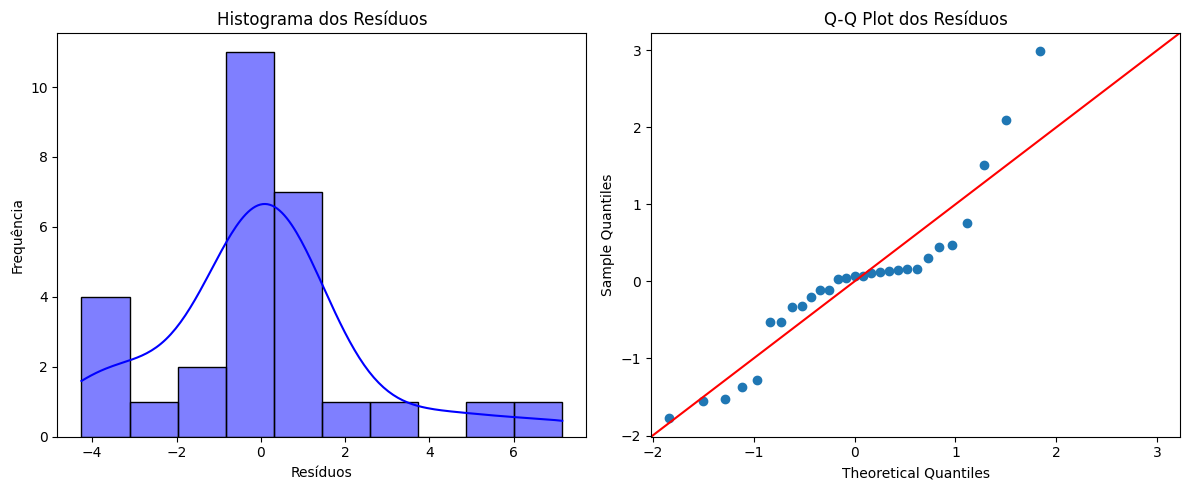

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(residuos, kde=True, ax=axes[0], color='blue',bins=10)

axes[0].set_title('Histograma dos Resíduos')
axes[0].set_xlabel('Resíduos')
axes[0].set_ylabel('Frequência')

# Q-Q Plot
sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout()
plt.show()

- Shapiro-wilk: p-valor = 0.0084
- Lilliefors: p-valor = 0.0064
- Anderso-Darling: estatística = 1.2563
- Jarque-Bera: p-valor = 0.0605

A hipótese nula (H0) de todos os testes é que os os resíduos são normalmente distribuídos, mas de acordo com os resultados obtidos (Os p-valor de todos os testes são menores que 0.05), pode-se rejeitar a hipótese nula e concluir que os resíduos não seguem uma distribuição normal. Isso pode ser observado no Q-Q plot, onde os pontos mais a ponta desviam fortemente da reta vermelha.

In [16]:
# Multicolinearidade

X = modelo_final.model.exog
variaveis = modelo_final.model.exog_names

FIV_data = pd.DataFrame()
FIV_data["Variavel"] = variaveis
FIV_data["FIV"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print("--- Multicolinearidade ---")
print(FIV_data.round(2).to_string(index=False))
print("\n")


--- Multicolinearidade ---
          Variavel    FIV
         Intercept 131.97
         Q('Tent')  41.55
        Q('Compl')  43.55
Q('Q("Por Tent")')   1.85
        Q('PerTD')   1.69
          Q('Int')   1.46




**Multicolinearidade (Fator de Inflação da Variância - FIV)**

O FIV é uma medida de multicolinearidade entre as variáveis independentes. Quanto maior o FIV, maior a multicolinearidade entre as variáveis. Um FIV maior que 10 indica uma forte multicolinearidade entre as variáveis.

Após os resultados pode-se concluir que há uma severa multicolinearidade entre as variáveis `Tent` e `Compl` (ambas acima de 40). Isso significa que não se pode ter um passe completo sem uma tentativa, então as duas grandezas crescem de forma quase linear.


--- Heteroscedasticidade ---
	Est. Multiplicador de Lagrange (LM): 10.8063
	p-valor (LM): 0.0554
	Est. F: 2.7322
	p-valor (F): 0.0444


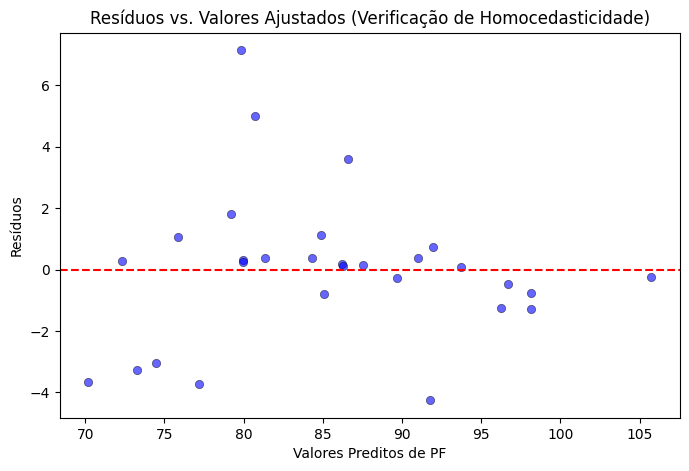

In [17]:
# Heteroscedasticidade

valores_ajustados = modelo_final.fittedvalues

bp_test = het_breuschpagan(residuos, X)
labels = ['Est. Multiplicador de Lagrange (LM)', 'p-valor (LM)', 'Est. F', 'p-valor (F)']

print("--- Heteroscedasticidade ---")

for label, valor in zip(labels, bp_test):
    print(f"\t{label}: {valor:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=valores_ajustados, y=residuos, color="blue", alpha=0.6, edgecolor="black")
plt.axhline(0, color="red", linestyle="--")
plt.title('Resíduos vs. Valores Ajustados (Verificação de Homocedasticidade)')
plt.xlabel('Valores Preditos de PF')
plt.ylabel('Resíduos')
plt.show()

**Heterocedasticidade**

Avalia se a variância dos resíduos é constante, ou se muda dependendo do valor predito. A hipótese nula é que a variância dos resíduos é constante (Homocedasticidade). Se o p-valor for menor que 0.05, rejeitamos a hipótese nula e concluímos que há heterocedasticidade.
A patir do p-valor de 0,044, obtido a partir do teste F, podemos concluir que os resíduos são levemente heterocedásticos, ou seja, a variância dos resíduos não é constante. Isso indica que a precisão do modelo muda a depender do nível de desempenho do jogador. 

In [18]:
df = data.copy()
df.rename(columns={'Por Tent': 'Por_Tent'}, inplace= True)

# Transformação Logarítmica 
df['log_PF'] = np.log(df['PF'])
modelo_log = smf.ols('log_PF ~ Tent + Compl + Por_Tent + PerTD + Int', data=df).fit()

sw_log_stat, sw_log_p = stats.shapiro(modelo_log.resid)
bp_log_p = het_breuschpagan(modelo_log.resid, modelo_log.model.exog)[1]

# Transformação Box-Cox

df['bc_PF'], lambda_bc = stats.boxcox(df['PF'])
modelo_bc = smf.ols('bc_PF ~ Tent + Compl + Por_Tent + PerTD + Int', data=df).fit()

sw_bc_stat, sw_bc_p = stats.shapiro(modelo_bc.resid)
bp_bc_p = het_breuschpagan(modelo_bc.resid, modelo_bc.model.exog)[1]

print("--- MODELO LOGARÍTMICO ---")
print(f"Shapiro-Wilk (Normalidade) p-valor: {sw_log_p:.4f}")
print(f"Breusch-Pagan (Homocedasticidade) p-valor: {bp_log_p:.4f}")
print(f"R² Ajustado: {modelo_log.rsquared_adj:.4f}\n")

print("--- MODELO BOX-COX ---")
print(f"Lambda otimizado: {lambda_bc:.4f}")
print(f"Shapiro-Wilk (Normalidade) p-valor: {sw_bc_p:.4f}")
print(f"Breusch-Pagan (Homocedasticidade) p-valor: {bp_bc_p:.4f}")
print(f"R² Ajustado: {modelo_bc.rsquared_adj:.4f}")


--- MODELO LOGARÍTMICO ---
Shapiro-Wilk (Normalidade) p-valor: 0.0244
Breusch-Pagan (Homocedasticidade) p-valor: 0.0429
R² Ajustado: 0.8909

--- MODELO BOX-COX ---
Lambda otimizado: 1.5398
Shapiro-Wilk (Normalidade) p-valor: 0.0148
Breusch-Pagan (Homocedasticidade) p-valor: 0.0659
R² Ajustado: 0.9238


**Modelo com Logaritimo**
- Normalidade (Shapiro-Wilk): p-valor = 0.0244

- Homocedasticidade (Breusch-Pagan): p-valor = 0.0429

Ambos os p-valores continuam abaixo de 0,05, os resíduos continuam não normais e o modelo continua com leve heterocedasticidade. O R² ajustado também não melhorou, demonstrando uma queda de 0,914 para 0,890

**Modelo com Box-Cox**
- $\lambda \approx 1.54$, significa que a transformação ideal não foi encolher a variável, mas sim elevá-la a uma potência, Fórmula aplicada foi aproximadamente: $Y' = \frac{Y^{1.54} - 1}{1.54}$.
- Homocedasticidade (Breusch-Pagan): p-valor = 0.0659
- Normalidade (Shapiro-Wilk): p-valor = 0.0148

O p-valor de Breusch-Pagan aumentou para acima de 0,05, o que significa que a heterocedasticidade foi reduzida. O R² ajustado também se mateve alto (0,9238), porém a normalidade ainda é rejeitada a 5% de significância.

**Análise de Componentes Principais**

O primeiro passo para efetuar a análise é separar as variáveis quantitativas (númericas). Considerando que os valores nulos já foram tratados anteriormente.

In [19]:
# Separando variáveis numéricas
X = df[['Tent', 'Compl', 'Por_Tent', 'TD','PerTD', 'Int']].values

# Padronizando os dados
X_scaled = StandardScaler().fit_transform(X)

# Executando PCA com o número máximo de componentes no momento
pca = PCA(n_components=6)
scores_pca = pca.fit_transform(X_scaled)

# Calculando a variância explicada por cada componente
var_individual = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_individual)

tabela_variancia = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(6)],
    'Variância Individual (%)': var_individual * 100,
    'Variância Acumulada (%)': var_acumulada * 100
})
print(tabela_variancia.round(2).to_string(index=False))


Componente  Variância Individual (%)  Variância Acumulada (%)
       PC1                     63.55                    63.55
       PC2                     17.69                    81.25
       PC3                     10.85                    92.10
       PC4                      7.60                    99.70
       PC5                      0.21                    99.91
       PC6                      0.09                   100.00


De acordo com os resultados da tabela de variância, o número ideal de componentes está entre 2 a 3. Contudo, vamos gerar um Scree Plot para confirmar os resultados.

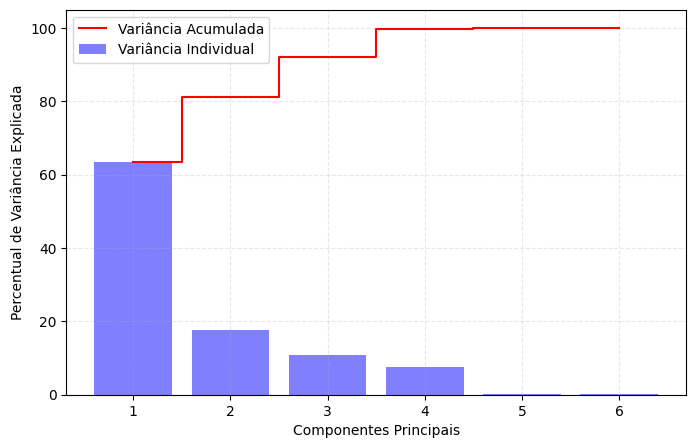

In [20]:
# Gerando Scree Plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, 7), var_individual * 100, color='blue', alpha=0.5, align='center', label='Variância Individual')
plt.step(range(1, 7), var_acumulada * 100, where='mid', label='Variância Acumulada', color='red')
plt.xlabel('Componentes Principais')
plt.ylabel('Percentual de Variância Explicada')
plt.xticks(range(1, 7))
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Com base no Scree Plot, nota-se que há um aumento significativo da variância acumulada entre PC1 e PC2, enquanto à partir de PC3 em diante, apesar de representar mais de 92%, o aumento reduz. Dessa forma, como o objetivo da PCA é utilizar o mínimo possível de variáveis para explicar o máximo possível de informações, optamos por utilizar apenas 2 componentes (PC1 e PC2).

In [21]:
pca_final = PCA(n_components=2)
valores_pca_final = pca_final.fit_transform(X_scaled)
valores_pca_final

array([[ 3.06333967,  2.60151329],
       [ 0.31835419,  0.32663845],
       [ 3.05235634, -0.28534995],
       [ 4.10395148, -0.19817589],
       [ 2.07885692, -0.21146076],
       [ 2.21974022,  0.34424877],
       [-0.39080406,  0.97679374],
       [ 1.69485326,  1.36583477],
       [-1.87200358, -0.05265393],
       [ 0.84661842, -0.35639924],
       [-0.02572472,  0.46455097],
       [-1.25040978,  2.25333711],
       [-2.48972637,  1.41406065],
       [ 0.30761613, -0.0196495 ],
       [ 1.15741093, -0.89080926],
       [ 2.60636602, -1.33179376],
       [-1.23651728, -0.28328747],
       [-0.23693121,  0.51629287],
       [-1.12107952, -1.40128666],
       [ 0.1266707 , -1.70228241],
       [ 1.8730339 , -1.4137218 ],
       [-0.70264659, -0.41550761],
       [-1.7949201 , -0.53329513],
       [-0.58115772, -0.05322809],
       [-1.22150028,  0.84039483],
       [-3.51566344,  0.11419445],
       [-1.37086421, -1.1662797 ],
       [-2.37173458, -1.02807392],
       [-3.26748476,

O próximo passo é montar uma tabela de scores e loadings para elaborar o Biplot.

In [22]:
# Tabela scores
tabela_scores = pd.DataFrame(valores_pca_final, columns=['PC1', 'PC2'])
tabela_scores_final = pd.concat([df['Jogador'].reset_index(drop=True), df['Time'].reset_index(drop=True), tabela_scores], axis=1)
tabela_scores_final.head()

,Jogador,Time,PC1,PC2
0,Philip Rivers,SD,3.063340,2.601513
1,Chad Pennington,MIA,0.318354,0.326638
2,Kurt Warner,ARI,3.052356,-0.285350
3,Drew Brees,NO,4.103951,-0.198176
4,Peyton Manning,IND,2.078857,-0.211461


In [23]:
# Tabela de loadings
loadings = pd.DataFrame(pca_final.components_.T, columns=['PC1', 'PC2'], index=['Tent', 'Compl', 'Por_Tent', 'TD','PerTD', 'Int'])
print(loadings.round(4).to_string())

             PC1     PC2
Tent      0.4410 -0.4417
Compl     0.4544 -0.3758
Por_Tent  0.3373  0.4965
TD        0.4917  0.1188
PerTD     0.3656  0.5913
Int       0.3314 -0.2311


Com ambas as tabelas, geramos um gráfico Biplot para analisar os resultados. Importante ressaltar que também concatenamos os nomes dos jogadores e suas respectivas equipes.

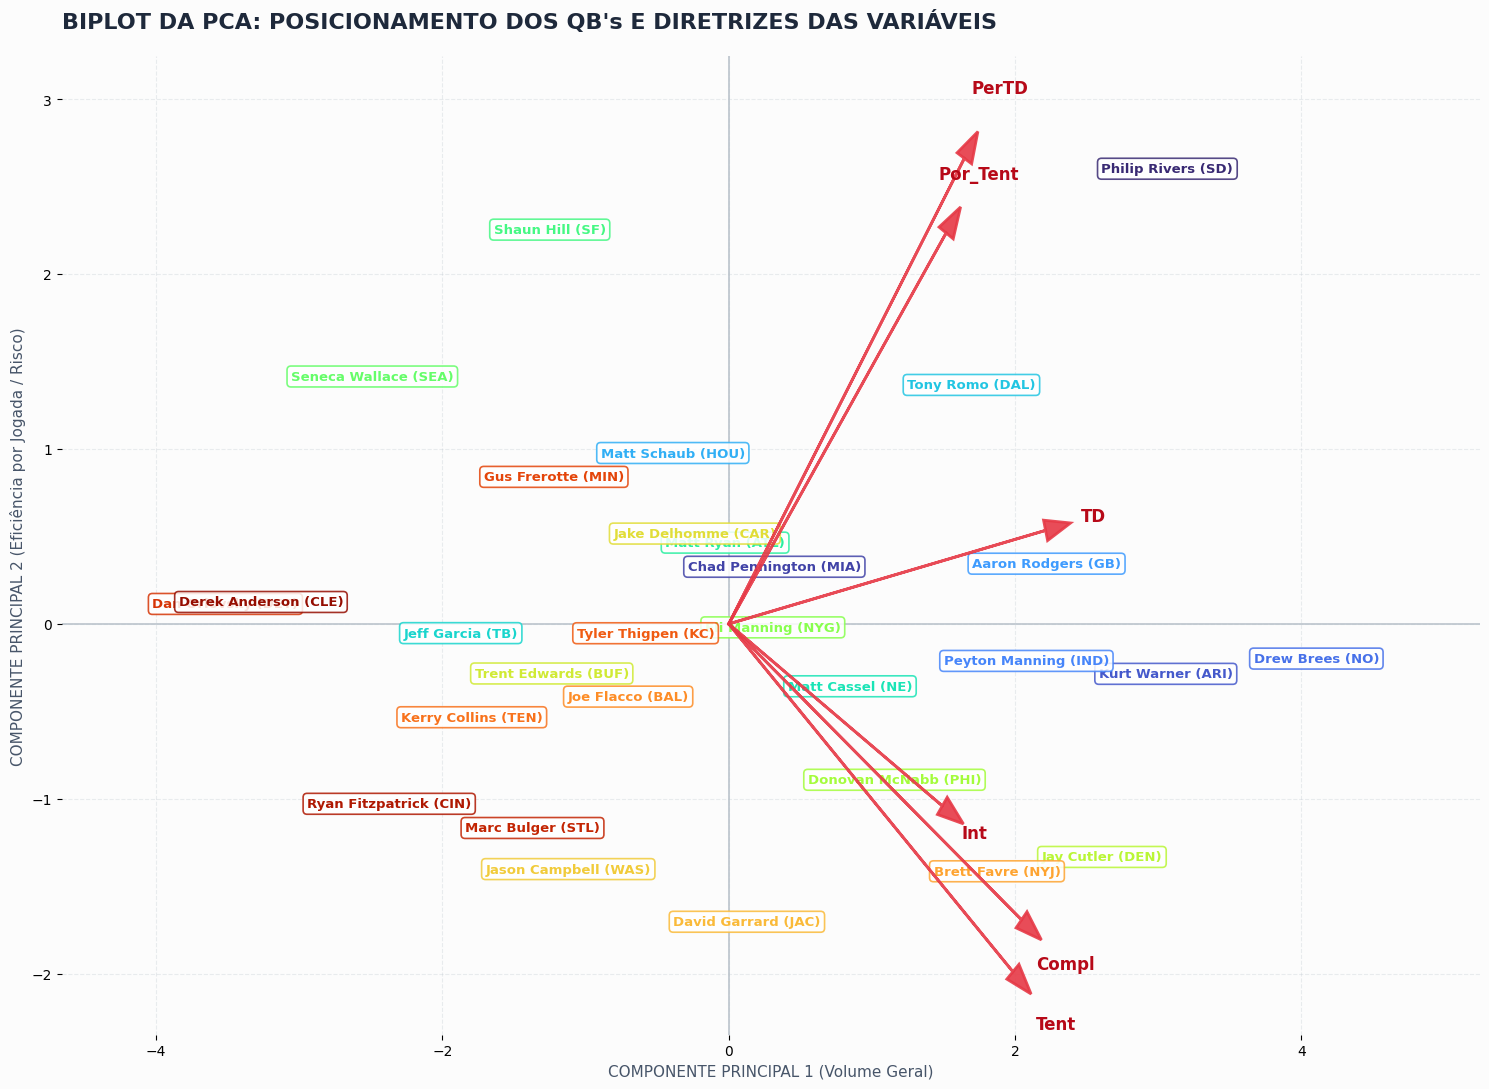

In [24]:
fig, ax = plt.subplots(figsize=(15, 11), dpi=100)
ax.set_facecolor('#fcfcfc')
fig.patch.set_facecolor('#fcfcfc')

# Cores para os times
times = tabela_scores_final['Time'].unique()
cores = sns.color_palette('turbo', n_colors=len(times))
paleta = dict(zip(times, cores))

# Plot jogadores (scores)
textos = []
for idx, row in tabela_scores_final.iterrows():
    cor_time = paleta[row["Time"]]
    ax.text(
        x=row["PC1"],
        y=row["PC2"],
        s=f"{row['Jogador']} ({row['Time']})",
        color=cor_time,
        fontsize=9.5,
        weight="bold",
        ha="center",
        va="center",
        zorder=2,
        bbox=dict(
            facecolor="#ffffff",
            alpha=0.85,
            edgecolor=cor_time,
            boxstyle="round,pad=0.3",
            linewidth=1.2,
        ),
    )

# Plot loadings
escala_vetores = 4.5

for i, var in enumerate(['Tent', 'Compl', 'Por_Tent', 'TD','PerTD', 'Int']):
    v_x = loadings.loc[var, "PC1"] * escala_vetores
    v_y = loadings.loc[var, "PC2"] * escala_vetores

    # Desenha a seta vermelha
    ax.arrow(
        0,
        0,
        v_x,
        v_y,
        color="#e63946",
        alpha=0.9,
        linewidth=2,
        head_width=0.12,
        zorder=3,
    )
    # Escreve o nome da variável na ponta da seta
    ax.text(
        v_x * 1.15,
        v_y * 1.15,
        var,
        color="#b70918",
        fontsize=12,
        weight="black",
        ha="center",
        va="center",
        zorder=4,
    )

ax.axhline(0, color="#bcc4cd", linestyle="-", linewidth=1.2, zorder=1)
ax.axvline(0, color="#bcc4cd", linestyle="-", linewidth=1.2, zorder=1)
ax.grid(True, linestyle="--", alpha=0.3, color="#bcc4cd")

pad_x = (tabela_scores["PC1"].max() - tabela_scores["PC1"].min()) * 0.15
pad_y = (tabela_scores["PC2"].max() - tabela_scores["PC2"].min()) * 0.15
ax.set_xlim(tabela_scores["PC1"].min() - pad_x, tabela_scores["PC1"].max() + pad_x)
ax.set_ylim(tabela_scores["PC2"].min() - pad_y, tabela_scores["PC2"].max() + pad_y)

ax.set_title(
    "BIPLOT DA PCA: POSICIONAMENTO DOS QB's E DIRETRIZES DAS VARIÁVEIS",
    fontsize=16,
    weight="bold",
    color="#1e293b",
    pad=20,
    loc="left",
)
ax.set_xlabel("COMPONENTE PRINCIPAL 1 (Volume Geral)", fontsize=11, color="#475569")
ax.set_ylabel(
    "COMPONENTE PRINCIPAL 2 (Eficiência por Jogada / Risco)",
    fontsize=11,
    color="#475569",
)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**Interpretação dos Componentes Principais**

- **PC1 - Volume de Jogo Geral:** Explica a maior parte da variabilidade dos dados (63,55%), as variáveis Tent(Tentativas), Compl(Passes Completados) e TD(Touchdowns) apontam fortemente para a direita. Dessa forma, quanto mais à direita um jogador estiver, maior é o seu volume de jogo bruto na temporada, ou seja, efetuam muitos passes e convertem muitos touchdowns.

- **PC2 - Eficiência por Jogada:** Corresponde a 17,69% da variabilidade. Os vetores Por_Tent(Jardas ganhas por tentativa) e PerTD(Porcentagem de tentativas convertidas em touchdowns) apontam para fortemente para cima. Portanto, PC2 mede a eficiência geral do jogador, determinando quantas jogadas efetuadas por ele são de fato convertidas.

Dessa forma, quanto mais para à direita no gráfico, maior o volume de jogo do atleta e quanto mais para cima, maior a eficiência. Podemos concluir que atletas como Philip Rivers, Tonny Romo e Aaron Rodgers são os mais eficientes e com grande volume de jogo no geral.